<a href="https://colab.research.google.com/github/sfaril12/E1E124049_SafarilAdam_MachineLearning/blob/main/Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Regresi: Prediksi Lama Rawat Inap (time_in_hospital)
## Algoritma: Linear Regression
## Fitur: Wajib + Rekayasa Fitur (total_visits, num_med_prescribed)
## Evaluasi: MAE, MSE, MAPE, R² | Split 70/30, 80/20, 90/10

## Tahap 1: Import Library

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
print('Library berhasil dimuat!')

Library berhasil dimuat!


## Tahap 2: Memuat Data

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/sfaril12/dataset_diabetes_perrcobaan/refs/heads/main/diabetic_data.csv')
print(f'Ukuran dataset awal: {df.shape[0]} baris x {df.shape[1]} kolom')

Ukuran dataset awal: 101766 baris x 50 kolom


## Tahap 3: Informasi Missing Values & Pembersihan Awal

In [16]:
df.replace('?', np.nan, inplace=True)
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_info = missing_pct[missing_pct > 0].sort_values(ascending=False)
print('Kolom dengan missing values:')
print(missing_info)

# Hapus duplikasi
df.drop_duplicates(inplace=True)

# Isi missing values diagnosis dengan modus
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col].fillna(df[col].mode()[0], inplace=True)

Kolom dengan missing values:
weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
dtype: float64


## Tahap 4: Rekayasa Fitur (Feature Engineering)

In [17]:
# 1. total_visits: Gabungan kunjungan RS setahun terakhir
df['total_visits'] = df['number_inpatient'] + df['number_emergency'] + df['number_outpatient']

# 2. num_med_prescribed: Jumlah obat diabetes yang aktif
diabetes_meds = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
                 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
                 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
                 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
                 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

# Pastikan kolom ada di df sebelum dihitung
meds_to_sum = [m for m in diabetes_meds if m in df.columns]
df['num_med_prescribed'] = sum((df[m] != 'No').astype(int) for m in meds_to_sum)

# 3. Grouping Diagnosis (ICD-9)
def map_diagnosis(diag):
    if pd.isna(diag): return 'Other'
    diag = str(diag).strip()
    if diag.startswith('V') or diag.startswith('E'): return 'External'
    try: code = float(diag)
    except ValueError: return 'Other'
    if 1 <= code <= 139: return 'Infectious'
    elif 140 <= code <= 239: return 'Neoplasms'
    elif 240 <= code <= 279: return 'Endocrine'
    elif 280 <= code <= 289: return 'Blood'
    elif 290 <= code <= 319: return 'Mental'
    elif 320 <= code <= 389: return 'Nervous'
    elif 390 <= code <= 459: return 'Circulatory'
    elif 460 <= code <= 519: return 'Respiratory'
    elif 520 <= code <= 579: return 'Digestive'
    elif 580 <= code <= 629: return 'Genitourinary'
    elif 630 <= code <= 679: return 'Pregnancy'
    elif 680 <= code <= 709: return 'Skin'
    elif 710 <= code <= 739: return 'Musculoskeletal'
    elif 740 <= code <= 759: return 'Congenital'
    elif 760 <= code <= 779: return 'Perinatal'
    elif 780 <= code <= 799: return 'Symptoms'
    elif 800 <= code <= 999: return 'Injury'
    else: return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_cat'] = df[col].apply(map_diagnosis)

print('Rekayasa fitur selesai.')

Rekayasa fitur selesai.


## Tahap 5: Seleksi Fitur & Target

In [18]:
# Target: time_in_hospital
target = 'time_in_hospital'

# Fitur Pilihan (Wajib + Rekayasa)
features = [
    # Riwayat Kunjungan
    'number_inpatient', 'number_emergency', 'number_outpatient', 'total_visits',
    # Keparahan & Kompleksitas
    'number_diagnoses', 'num_lab_procedures', 'num_procedures', 'num_medications',
    # Profil & Diagnosis
    'age', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat',
    # Medikasi
    'insulin', 'metformin', 'change', 'diabetesMed', 'num_med_prescribed'
]

X_raw = df[features].copy()
y = df[target].copy()

# Label Encoding untuk kategorikal
cat_cols = X_raw.select_dtypes(include='object').columns
for col in cat_cols:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))

print(f'Fitur yang digunakan ({len(features)}): {features}')

Fitur yang digunakan (17): ['number_inpatient', 'number_emergency', 'number_outpatient', 'total_visits', 'number_diagnoses', 'num_lab_procedures', 'num_procedures', 'num_medications', 'age', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'insulin', 'metformin', 'change', 'diabetesMed', 'num_med_prescribed']


## Tahap 6: Heatmap Korelasi

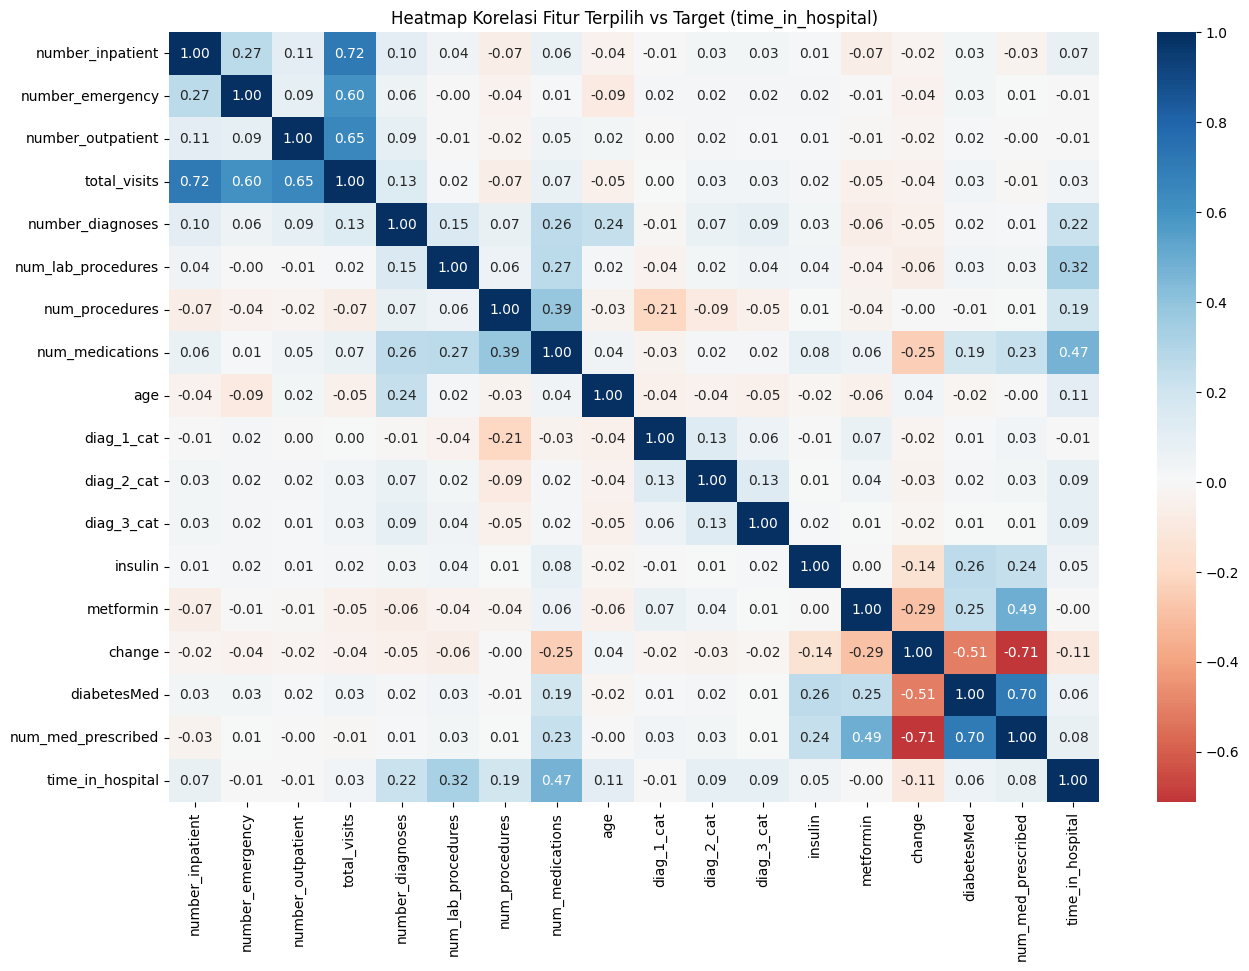

In [19]:
plt.figure(figsize=(15, 10))
sns.heatmap(pd.concat([X_raw, y], axis=1).corr(), annot=True, fmt='.2f', cmap='RdBu', center=0)
plt.title('Heatmap Korelasi Fitur Terpilih vs Target (time_in_hospital)')
plt.show()

## Tahap 7: Standardisasi & PCA

Jumlah komponen optimal (95% varians): 14


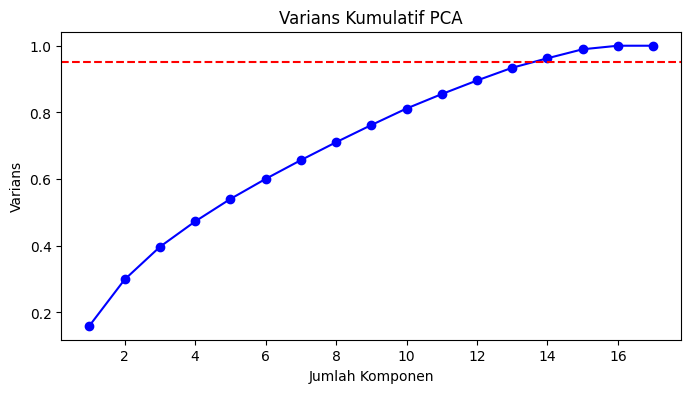

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

pca_all = PCA().fit(X_scaled)
cum_var = np.cumsum(pca_all.explained_variance_ratio_)
n_opt = np.argmax(cum_var >= 0.95) + 1

print(f'Jumlah komponen optimal (95% varians): {n_opt}')

pca = PCA(n_components=n_opt)
X_pca = pca.fit_transform(X_scaled)

# Visualisasi PCA
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, 'bo-')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('Varians Kumulatif PCA')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Varians')
plt.show()

## Tahap 8: Fungsi Evaluasi MAPE

In [21]:
def mape_score(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

## Tahap 9: Training & Evaluasi (Linear Regression)

In [22]:
splits = [(0.3, '70/30'), (0.2, '80/20'), (0.1, '90/10')]
final_results = []

for test_sz, label in splits:
    print(f'\n>>> MENGUJI SPLIT {label}')

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_sz, random_state=42)
    X_train_p, X_test_p, _, _ = train_test_split(X_pca, y, test_size=test_sz, random_state=42)

    # 1. Tanpa PCA
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    res_raw = {
        'Split': label, 'Mode': 'Tanpa PCA',
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'MAPE': mape_score(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    }
    final_results.append(res_raw)

    # 2. Dengan PCA
    model_p = LinearRegression()
    model_p.fit(X_train_p, y_train)
    y_pred_p = model_p.predict(X_test_p)

    res_pca = {
        'Split': label, 'Mode': 'Dengan PCA',
        'MAE': mean_absolute_error(y_test, y_pred_p),
        'MSE': mean_squared_error(y_test, y_pred_p),
        'MAPE': mape_score(y_test, y_pred_p),
        'R2': r2_score(y_test, y_pred_p)
    }
    final_results.append(res_pca)

# Tampilkan Hasil
df_res = pd.DataFrame(final_results)
display(df_res)


>>> MENGUJI SPLIT 70/30

>>> MENGUJI SPLIT 80/20

>>> MENGUJI SPLIT 90/10


,Split,Mode,MAE,MSE,MAPE,R2
0,70/30,Tanpa PCA,1.917461,6.345202,67.965191,0.283488
1,70/30,Dengan PCA,1.930922,6.414080,68.798949,0.275710
2,80/20,Tanpa PCA,1.903972,6.222297,67.957420,0.285128
3,80/20,Dengan PCA,1.917877,6.290300,68.807119,0.277316
4,90/10,Tanpa PCA,1.887686,6.157030,67.679376,0.290571
5,90/10,Dengan PCA,1.904435,6.236959,68.615320,0.281361


## Tahap 10: Visualisasi Hasil Akhir

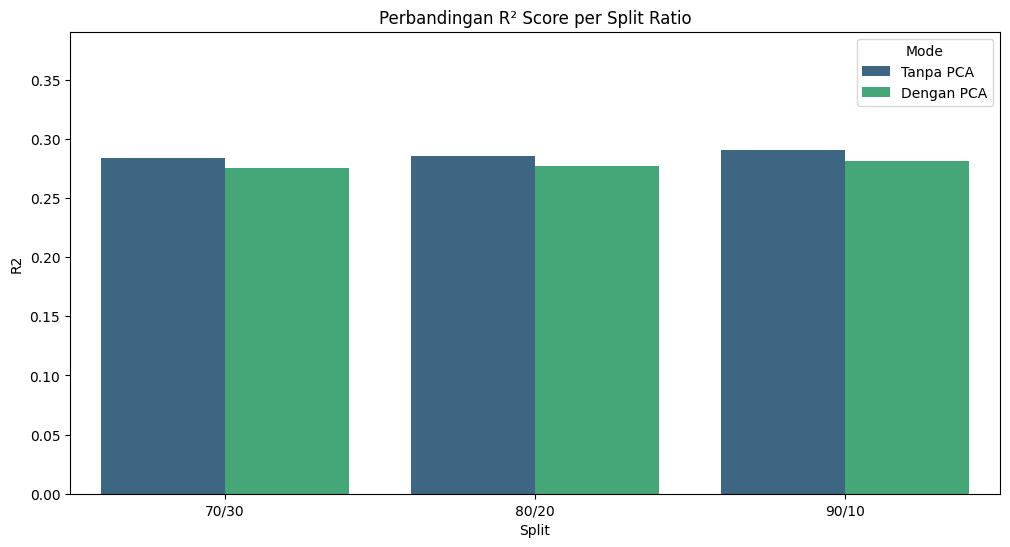

In [23]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x='Split', y='R2', hue='Mode', palette='viridis')
plt.title('Perbandingan R² Score per Split Ratio')
plt.ylim(0, df_res['R2'].max() + 0.1)
plt.show()

## Tahap 11: Kesimpulan

In [24]:
best = df_res.loc[df_res['R2'].idxmax()]
print(f'Model terbaik ditemukan pada Split {best["Split"]} ({best["Mode"]}) dengan R²: {best["R2"]:.4f}')

Model terbaik ditemukan pada Split 90/10 (Tanpa PCA) dengan R²: 0.2906
